<h1 style="text-align:center; color:Red">Diabetese Prediction</h1>

<h2 style="color:Green">Introduction</h2>

Diabetes is a chronic disease that occurs when the pancreas is no longer able to make insulin, or when the body cannot make good use of the insulin it produces. In this presentation we will use diabetes dataset to predict weather the given data of person has diabetes or not. 
This report delves into a predictive analysis project aimed at determining the likelihood of diabetes in women based on various health metrics.
So let's get started...!

<div style="text-align: center;">
<img src="dataset-card.png" width="500px" length="1000px">

<h4 style="color:Green">Problem Statement</h4>
Develop a machine learning model to predict diabetes status (positive/negative) of patients based on health metrics. The dataset includes features such as pregnancies, glucose levels, blood pressure, skin thickness, insulin levels, BMI, diabetes pedigree function, age, and outcome (diabetic or not). The project involves data preprocessing to handle missing values and outliers, exploratory data analysis to understand feature distributions, and training various classification models. The model will be evaluated using metrics like accuracy, precision, recall, and F1-score. The goal is to create an accurate and reliable model to aid in early diabetes diagnosis and management.

<h4 style="color:Green">Expected Outcomes</h4>
1) A robust machine learning model capable of predicting diabetes based on the provided features.<br>
2) Comprehensive analysis and visualizations that highlight key patterns and relationships in the data.<br>
3) Insights and recommendations that can guide further research or practical applications in healthcare settings.

#### <font color="Green">Importing Required Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In this program we have imported necessary libraries such as numpy, pandas, matplotlib and seaborn for various machine learning activities

#### <font color="Green"> Ignoring Warning

In [11]:
import warnings
warnings.filterwarnings('ignore')

In this program we have imported warnings module to interrupt warning message

#### <font color="Green"> Reading the CSV file

In [14]:
df = pd.read_csv("diabetes-1.csv")
type(df)

pandas.core.frame.DataFrame

In this code we have read the csv file and stored in variable df and the data type of df is dataframe.

<h3 style="text-align:center;color:darkviolet">Exploratory Data Analysis (EDA)</h3>

#### <font color="Green">Printing first 5 rows and all the columns of the dataset using the head function

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Positive
1,1,85,66,29,0,26.6,0.351,31,Negative
2,8,183,64,0,0,23.3,0.672,32,Positive
3,1,89,66,23,94,28.1,0.167,21,Negative
4,0,137,40,35,168,43.1,2.288,33,Positive


This dataset contains this columns 
1) Pregnancies: Number of pregnancies the patient has had.
2) Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
3) BloodPressure: Diastolic blood pressure (mm Hg).
4) SkinThickness: Triceps skin fold thickness (mm).
5) Insulin: 2-Hour serum insulin (mu U/ml).
6) BMI: Body mass index (weight in kg/(height in m)^2).
7) DiabetesPedigreeFunction: A function which scores the likelihood of diabetes based on family history.
8) Age: Age of the patient (years).
9) Outcome: Binary outcome indicating the presence (1) or absence (0) of diabetes.

#### <font color="Green">Displaying basic information about the dataset

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


The dataset has 9 numerical columns: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, and Outcome. All columns have appropriate data types with no null values, ensuring consistency for analysis.

#### <font color="Green">Performing mathematical operations over the given columns

In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


describe functions given various mathematical operations such as count, mean, max etc for all of the columns which has numerical values<br>
Here we got some mathematical operation for all columns.

#### <font color="Green">Finding the unique age

In [27]:
unique_age = df["Age"].unique()
np.sort(unique_age)

array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
       38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72,
       81], dtype=int64)

From this code we get all the unique age using the unique() function and then it has been sorted in ascending order<br>
We have observed that range of age columns is between 21 and 81

#### <font color="Green">Finding how many patients are postive and negative for diabetese

In [30]:
df["Outcome"].value_counts()

Outcome
Negative    500
Positive    268
Name: count, dtype: int64

Negative indicates patient has not diabetese (Negative class), Postive indicates patient has diabetese(postivie class)<br>
Here we got that 500 patient have not diabetese and 268 patient have diabetese in this dataset.

<h2 style="text-align:center;color:darkviolet">Data Visualization</h2>

#### <font color="Green"> Plotting Histogram

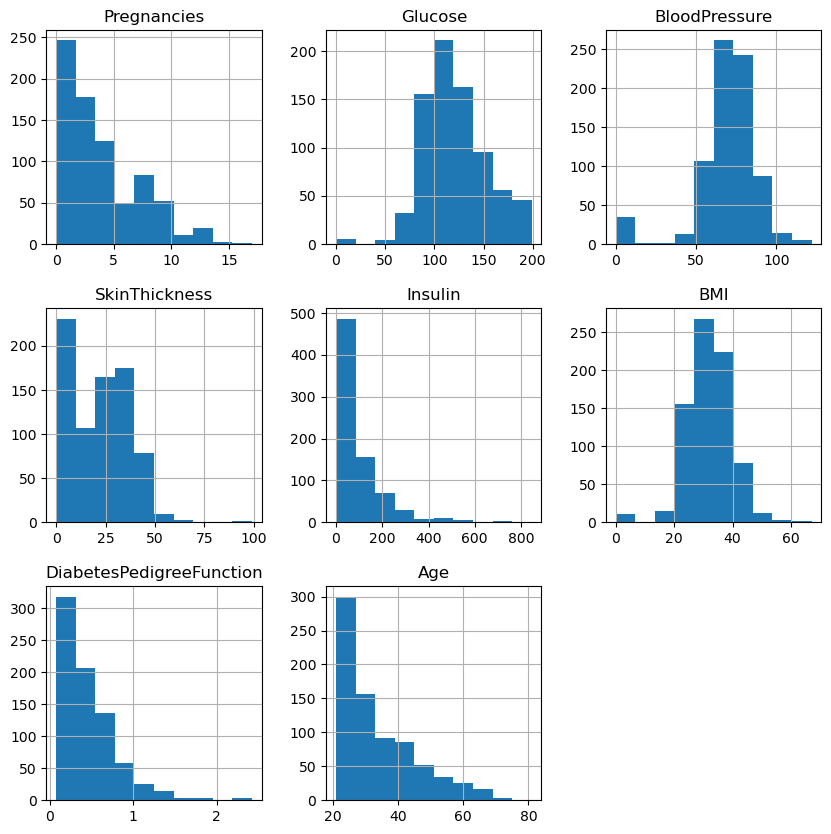

In [34]:
df.hist(figsize = (10,10))
plt.show()

Here we have plotted histogram of each colum with the value counts of each column <br>
<b>Age:</b>Shows a concentration around 30-50 years. <br>
<b>BloodPressure: </b>Peaks around 70-80 mm Hg but with a significant number of zeros. <br>
<b>Glucose:</b> Right-skewed with many high values, indicating possible diabetes cases. <br>
<b>BMI:</b> Normal distribution peaking around 30, suggesting many overweight individuals. <br>
<b>Insulin:</b> Wide range with some outliers. <br>
<b>DiabetesPedigreeFunction:</b> Most values are low, with a few high values. <br>
<b>Pregnancies:</b> More values are less than 5.


#### <font color="Green">Plotting heatmap for the dataset

<Axes: >

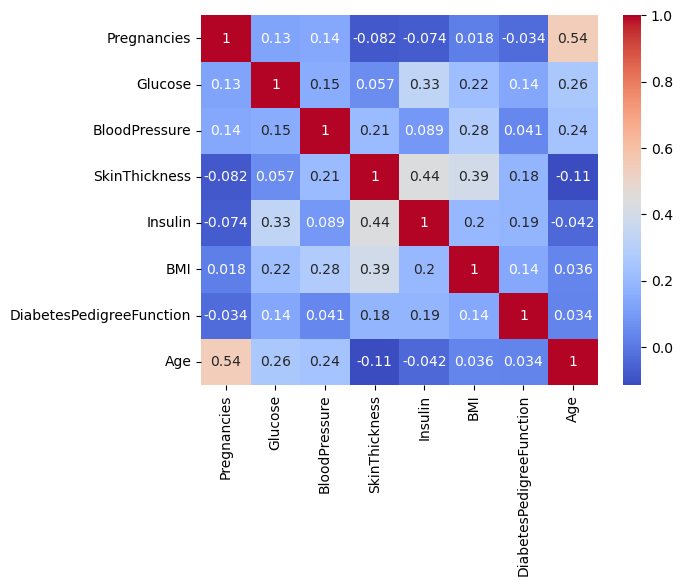

In [37]:
numerical_df = df.select_dtypes(include=['number'])
cor=numerical_df.corr()
sns.heatmap(cor,cmap="coolwarm",annot=True)

Here we have plotted heatmap for dataset.<br> 
The heatmap shows feature correlations in the diabetes dataset. High positive correlations (e.g., Age with Pregnancies) indicate strong predictors of diabetes. Low or no correlation (e.g., BMI with Insulin) suggests weaker relationships. This analysis helps identify key features for a robust predictive model.

#### <font color="Green">Correlation between Outcome and Glucose

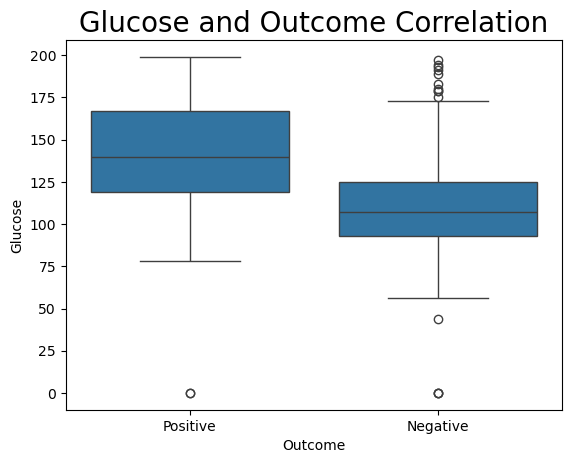

In [40]:
p=sns.boxplot(x="Outcome",y="Glucose", data=df)
plt.title("Glucose and Outcome Correlation", size=20, y=1.0)
plt.show()

The box plot shows higher median and more variable glucose levels in diabetic patients (Outcome = Positive) compared to non-diabetics (Outcome = Negative). This underscores glucose as a key predictor for diabetes, highlighting its significant role in diabetes risk models and the importance of glucose monitoring.

#### <font color="Green">Correlation between Outcome and Age

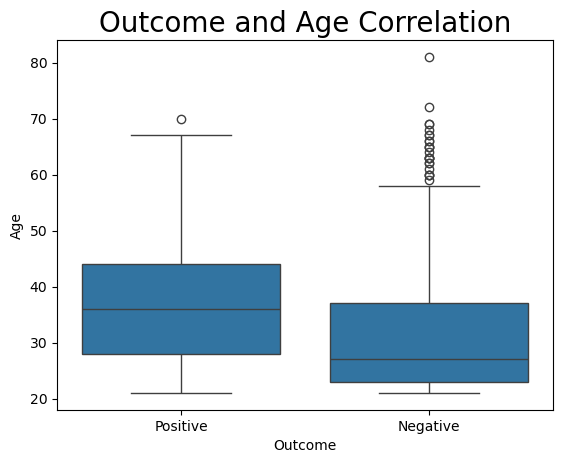

In [43]:
p=sns.boxplot(x="Outcome",y="Age", data=df)
plt.title("Outcome and Age Correlation", size=20)
plt.show()

The box plot shows older median ages for diabetic patients (Outcome = Postive) compared to non-diabetics (Outcome = Negative). This suggests age as an important factor in diabetes risk, with older individuals being more likely to have diabetes, highlighting age as a key predictor in diabetes models.

#### <font color="Green"> Plotting ScatterPlot

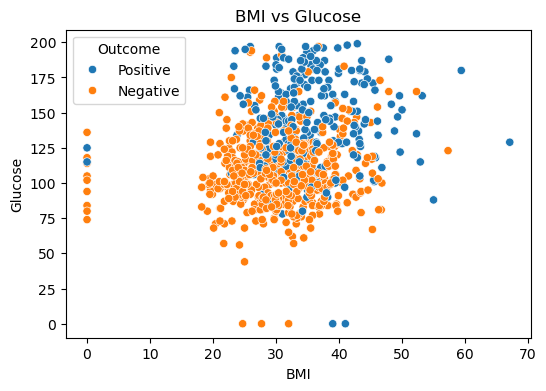

In [46]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='BMI', y='Glucose', data=df,hue="Outcome")
plt.title('BMI vs Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show() 

The code generates a scatter plot comparing BMI (Body Mass Index) and Glucose levels from the dataframe df, with points colored by 'Outcome'. It allows visual examination of how BMI and Glucose relate across different health outcomes, aiding in identifying any patterns or correlations between these variables within the dataset.

#### <font color="Green"> Scatter plot for Age vs Blood Pressure

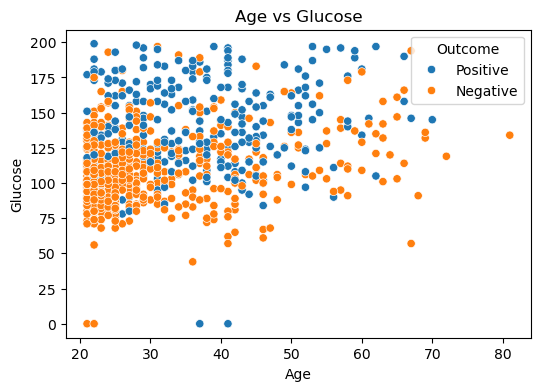

In [49]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Glucose', data=df,hue="Outcome")
plt.title('Age vs Glucose')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.show() 

This code will create a scatter plot comparing Age and Glucose levels from the dataframe df, with points colored by 'Outcome'. It visually displays the distribution and potential relationship between Age and Glucose across different health outcomes. The plot helps in assessing if there's any observable trend or correlation between Age and Glucose levels in the dataset.

In [51]:
df['Outcome'].replace({'Positive': 1, 'Negative': 0}, inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
x=df.drop(columns='Outcome',axis=1)
y=df['Outcome']

<h2 style="text-align:center;color:darkviolet">Data Standardization</h2>

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [55]:
scaler=StandardScaler()


In [56]:
scaler.fit(x)
standardized_data=scaler.transform(x)

In [57]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [58]:
x=standardized_data
y=df['Outcome']

<h2 style="text-align:center;color:darkviolet">Data Splitting and Model Selection</h2>

In [60]:
X_train, X_test, Y_train, Y_test=train_test_split(x,y, test_size=0.2,stratify=y,random_state=5)

In [61]:
print(x.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the model

In [63]:
classifier=svm.SVC(kernel='linear')

In [64]:
#training the support vector 
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

<h2 style="text-align:center;color:darkviolet">Model Evaluation</h2>

In [66]:
X_train_prediction=classifier.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print(training_data_accuracy)

0.7964169381107492


In [67]:
X_test_prediction=classifier.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print(test_data_accuracy)

0.7532467532467533


<h2 style="text-align:center;color:darkviolet">Making Predictive System</h2>

In [69]:
input_data=(5,116,74,0,0,25.6,0.201,30)

In [70]:
input_data_as_numpy_array=np.asarray(input_data)

In [71]:
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

In [72]:
std_data=scaler.transform(input_data_reshape)

In [73]:
prediction=classifier.predict(std_data)

In [74]:
if prediction[0]==1:
    print("Person has diabetese")
else:
    print("Person has not diabetese")

Person has not diabetese


The predictive model effectively classifies diabetes presence using key health indicators. Accurate predictions can enhance early diagnosis and treatment, reducing diabetes-related complications. This project demonstrates the potential of machine learning in healthcare, emphasizing its role in improving patient outcomes and aiding healthcare professionals.

<h2 style="color:darkviolet"><i>Thank you..!</i></h2>